# Hamiltonian Monte Carlo Parameter Estimation

This notebook compares three parameter estimation methods for the
`SimpleLinearGaussianSSM` on synthetic data:

| Method | Target | Cost per iteration |
|--------|--------|-------------------|
| **MLE** | $\hat\theta = \arg\max \ell(\theta;y)$ | 1 Kalman pass |
| **Metropolis-Hastings (MH)** | $p(\theta\mid y) \propto p(y\mid\theta)$ | 1 Kalman pass |
| **Hamiltonian MC (HMC)** | $p(\theta\mid y) \propto p(y\mid\theta)$ | $L+2$ Kalman passes |

Both MCMC methods use a flat prior on the constrained parameter space
$(\phi,\alpha,\sigma^2,\tau^2)$, so their posterior modes should agree
with the MLE.

HMC exploits the analytic score $\nabla_\theta\ell$ (propagated through
the Kalman recursion) to propose correlated, large moves that explore the
posterior far more efficiently than a random walk.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

from models.linear_gaussian import SimpleLinearGaussianSSM
from estimation.mle_estimator import MLEEstimator
from estimation.metropolis_hastings import MetropolisHastings
from estimation.hamilton_mc import HamiltonianMC

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

---
## 1. Synthetic data

$$
x_t = \phi\, x_{t-1} + \varepsilon_t,\quad
y_t = \alpha\, x_t + \eta_t,\quad
\varepsilon_t\sim\mathcal N(0,\sigma^2),\quad
\eta_t\sim\mathcal N(0,\tau^2)
$$

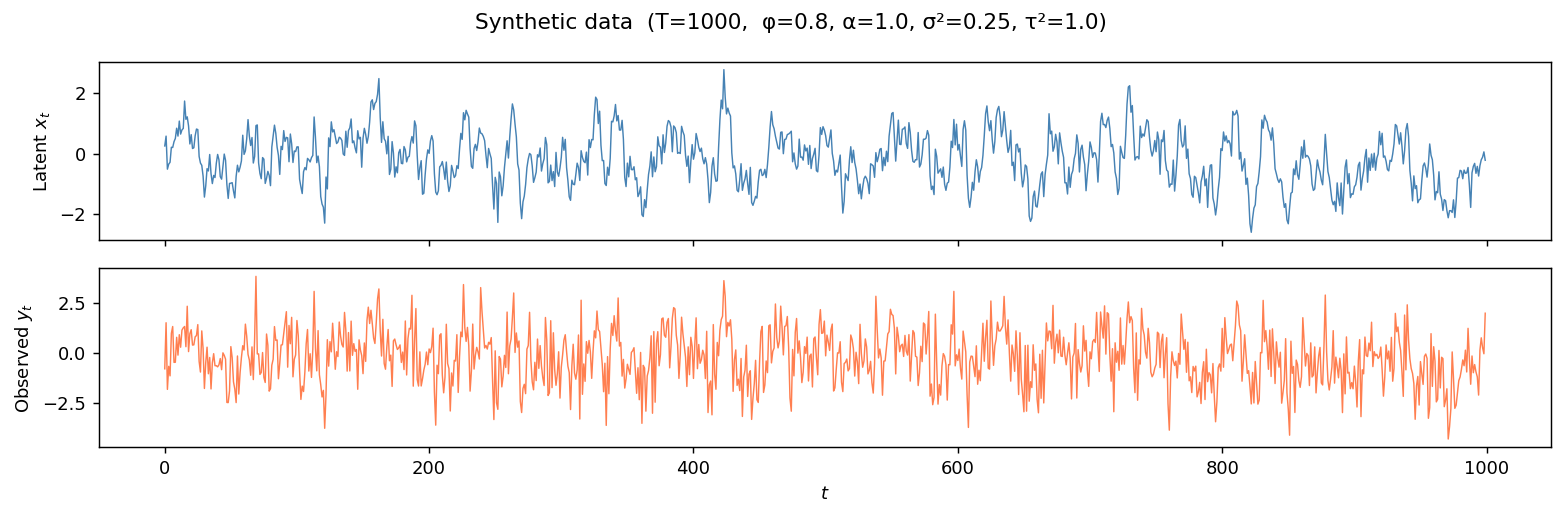

In [26]:
TRUE = dict(phi=0.80, alpha=1.0, sigma2=0.25, tau2=1.0)
PARAM_NAMES = ['phi', 'alpha', 'sigma2', 'tau2']
T    = 1000
SEED = 42

true_model = SimpleLinearGaussianSSM(**TRUE, seed=SEED)
states_raw, obs_raw, _ = true_model.generate_data(T)
states = states_raw.ravel()
obs    = obs_raw.ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(states, lw=0.8, color='steelblue'); axes[0].set_ylabel('Latent $x_t$')
axes[1].plot(obs,    lw=0.8, color='coral');     axes[1].set_ylabel('Observed $y_t$')
axes[1].set_xlabel('$t$')
fig.suptitle(f'Synthetic data  (T={T},  φ={TRUE["phi"]}, α={TRUE["alpha"]}, σ²={TRUE["sigma2"]}, τ²={TRUE["tau2"]})')
plt.tight_layout()
plt.show()

---
## 2. Maximum Likelihood Estimation

L-BFGS-B optimization in unconstrained space
$(u_\phi, u_\alpha, u_{\sigma^2}, u_{\tau^2})$
where $\phi=\tanh(u_\phi)$, $\sigma^2=\exp(u_{\sigma^2})$, $\tau^2=\exp(u_{\tau^2})$.

In [27]:
mle_model = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=1.0, tau2=1.0, seed=SEED)
theta0_mle = mle_model.unconstrain_params([0.5, 1.0, 1.0, 1.0])

mle = MLEEstimator(mle_model, obs, n_restarts=3, seed=SEED)
mle_result = mle.fit(theta0=theta0_mle)
mle.compute_std_errors()

print(mle_result.summary())

MLEEstimator.fit  0.380s
MLEResult  loglik=-1636.5243  converged  n_evals=130
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.806433      0.041016
  alpha                 0.519766             —
  sigma2                1.036899             —
  tau2                  1.044786      0.083624


---
## 3. Metropolis-Hastings

Random-walk MH in unconstrained space. The target is
$\pi(u) \propto p(y\mid\theta(u))\,|\det J(u)|$,
which corresponds to a flat prior on the constrained parameters.

In [28]:
N_MH   = 8_000
BURN   = 2_000

mh_model = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=1.0, tau2=1.0, seed=SEED)
theta0   = mh_model.unconstrain_params([0.5, 1.0, 1.0, 1.0])

mh = MetropolisHastings(
    model       = mh_model,
    data        = obs,
    n_iter      = N_MH,
    step_sizes  = np.array([0.08, 0.12, 0.12, 0.12]),
    theta0      = theta0,
    prior_space = 'constrained',
    seed        = SEED,
)
mh_chain, mh_loglik, mh_accepted = mh.run()

mh_con   = mh_model.constrain_chain(mh_chain[BURN:])
mh_means = mh_con.mean(axis=0)
mh_stds  = mh_con.std(axis=0)

print(f'MH acceptance rate: {mh.accept_rate:.3f}  (post-burn samples: {len(mh_con)})')

MetropolisHastings.run  8.790s
MH acceptance rate: 0.111  (post-burn samples: 6001)


---
## 4. Hamiltonian Monte Carlo

HMC uses the analytic score $\nabla_\theta\ell$ (propagated through the Kalman
recursion in one forward pass) to propose joint, gradient-guided moves.  Each
iteration runs $L$ leapfrog steps of size $\varepsilon$, giving proposals that
travel $O(\varepsilon L)$ along the posterior surface before accepting/rejecting.

In [29]:
N_HMC      = 4_000
BURN_HMC   = 500
STEP_SIZE  = 0.06
N_LEAPFROG = 12

hmc_model = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=1.0, tau2=1.0, seed=SEED)
theta0_h  = hmc_model.unconstrain_params([0.5, 1.0, 1.0, 1.0])

hmc = HamiltonianMC(
    model       = hmc_model,
    data        = obs,
    n_iter      = N_HMC,
    step_size   = STEP_SIZE,
    n_leapfrog  = N_LEAPFROG,
    theta0      = theta0_h,
    prior_space = 'constrained',
    seed        = SEED,
)
hmc_chain, hmc_loglik, hmc_accepted = hmc.run()

hmc_con   = hmc_model.constrain_chain(hmc_chain[BURN_HMC:])
hmc_means = hmc_con.mean(axis=0)
hmc_stds  = hmc_con.std(axis=0)

print(f'HMC acceptance rate: {hmc.accept_rate:.3f}  (step_size={STEP_SIZE}, L={N_LEAPFROG})')
print(f'Post-burn samples: {len(hmc_con)}')

HamiltonianMC.run  623.464s
HMC acceptance rate: 0.482  (step_size=0.06, L=12)
Post-burn samples: 3501


---
## 5. Comparison table

In [30]:
mle_est = list(mle_result.constrained_params)
mle_se  = mle_result.std_errors if mle_result.std_errors is not None else [float('nan')]*4

hdr = f"{'Param':<8}  {'True':>8}  {'MLE':>10}  {'MLE SE':>8}  "\
      f"{'MH mean':>10}  {'MH std':>8}  {'HMC mean':>10}  {'HMC std':>8}"
print(hdr)
print('-' * len(hdr))
for j, p in enumerate(PARAM_NAMES):
    print(
        f"{p:<8}  {TRUE[p]:>8.4f}  {mle_est[j]:>10.4f}  {mle_se[j]:>8.4f}  "
        f"{mh_means[j]:>10.4f}  {mh_stds[j]:>8.4f}  "
        f"{hmc_means[j]:>10.4f}  {hmc_stds[j]:>8.4f}"
    )

Param         True         MLE    MLE SE     MH mean    MH std    HMC mean   HMC std
------------------------------------------------------------------------------------
phi         0.8000      0.8064    0.0410      0.7905    0.0469      0.7927    0.0427
alpha       1.0000      0.5198       nan      0.1953    0.1474      1.0413    0.8832
sigma2      0.2500      1.0369       nan      9.7136    7.1293      0.6591    0.4565
tau2        1.0000      1.0448    0.0836      1.0238    0.0830      1.0415    0.0774


---
## 6. Trace plots

The grey band shows the burn-in period (discarded).  The red dashed line is the
MLE estimate; the green line is the true value.

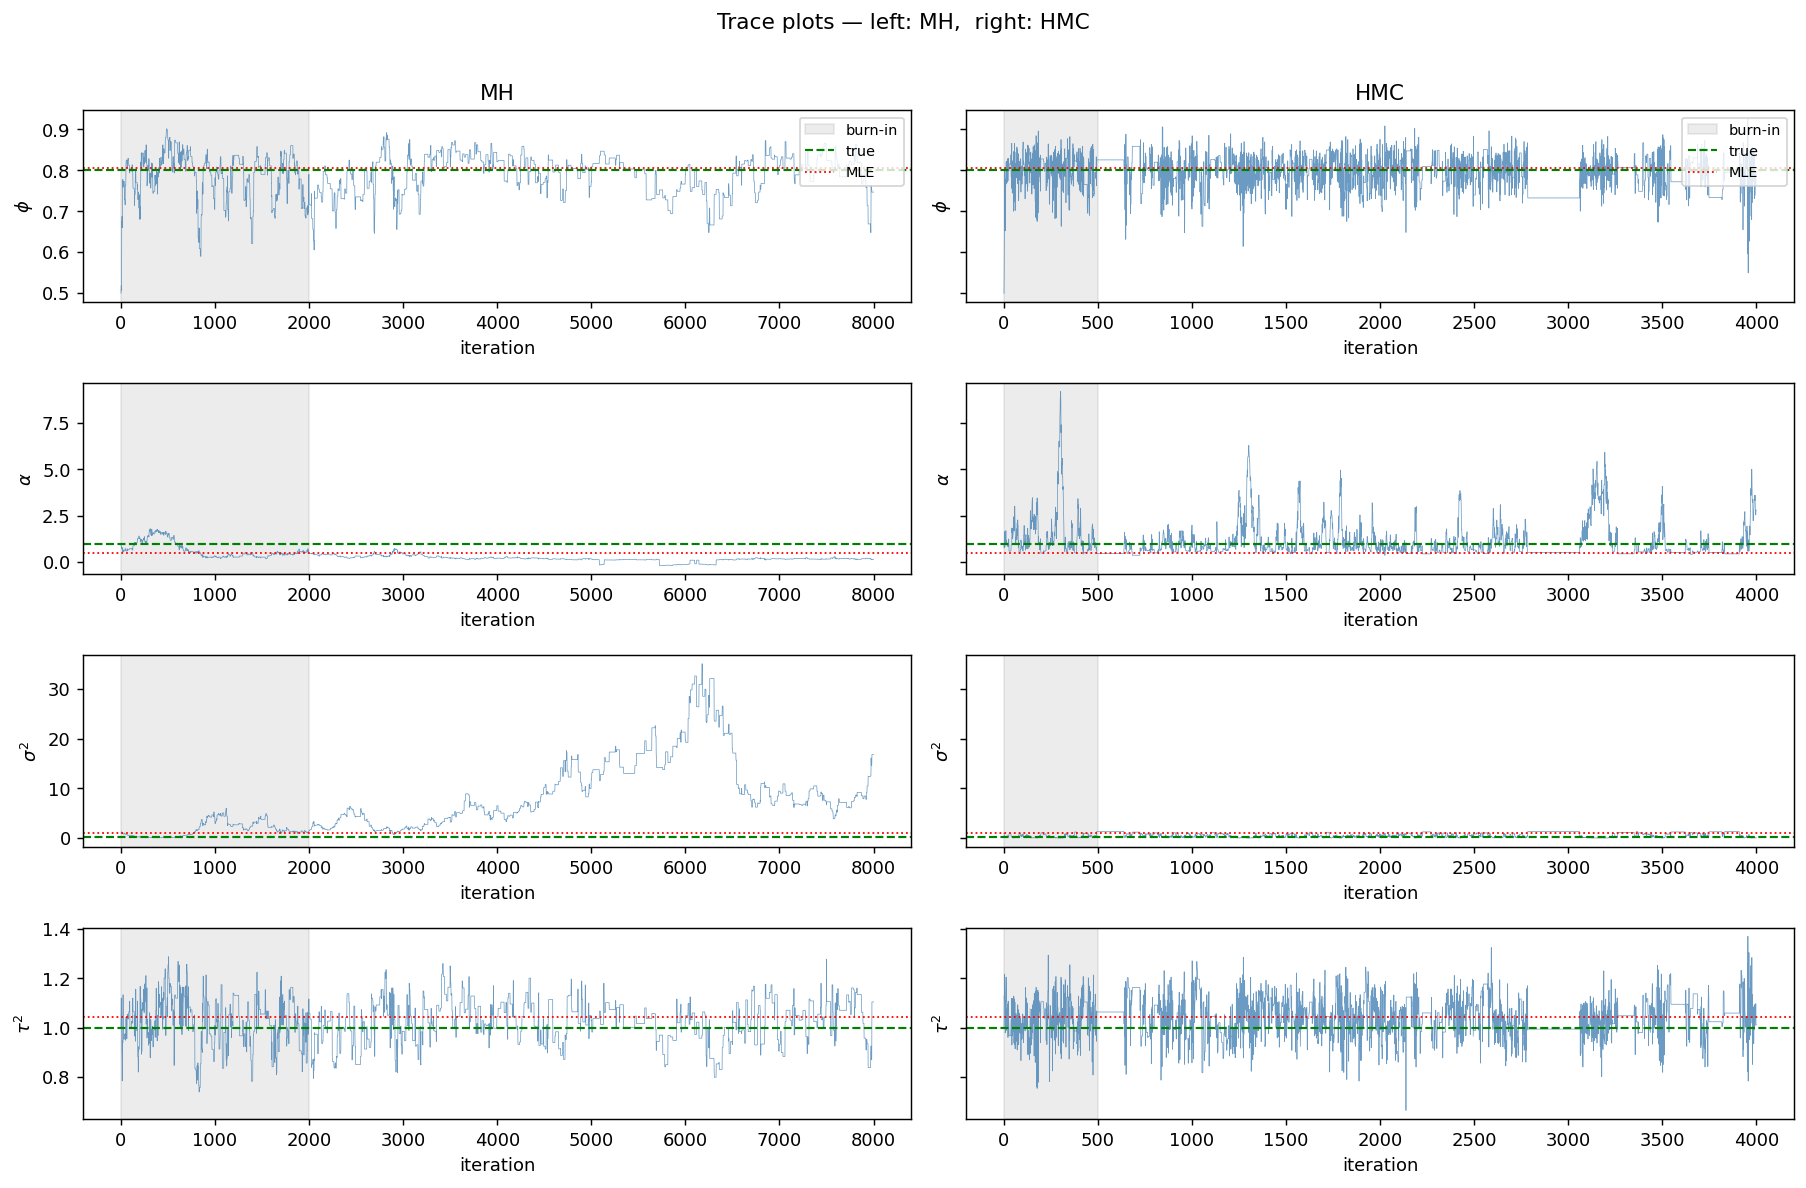

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(14, 9), sharey='row')
fig.suptitle('Trace plots — left: MH,  right: HMC', fontsize=12, y=1.01)

labels = [r'$\phi$', r'$\alpha$', r'$\sigma^2$', r'$\tau^2$']

for j, (label, param) in enumerate(zip(labels, PARAM_NAMES)):
    for col, (chain_con, burn, method) in enumerate([
        (mh_model.constrain_chain(mh_chain),   BURN,     'MH'),
        (hmc_model.constrain_chain(hmc_chain), BURN_HMC, 'HMC'),
    ]):
        ax = axes[j, col]
        ax.plot(chain_con[:, j], lw=0.4, alpha=0.8, color='steelblue')
        ax.axvspan(0, burn, color='grey', alpha=0.15, label='burn-in')
        ax.axhline(TRUE[param],    color='green',  lw=1.2, ls='--', label='true')
        ax.axhline(mle_est[j],     color='red',    lw=1.0, ls=':',  label='MLE')
        ax.set_ylabel(label)
        if j == 0:
            ax.set_title(method)
            ax.legend(fontsize=8, loc='upper right')
        ax.set_xlabel('iteration')

plt.tight_layout()
plt.show()

---
## 7. Posterior density comparison

KDE of post-burn samples for MH and HMC, with MLE and true value marked.

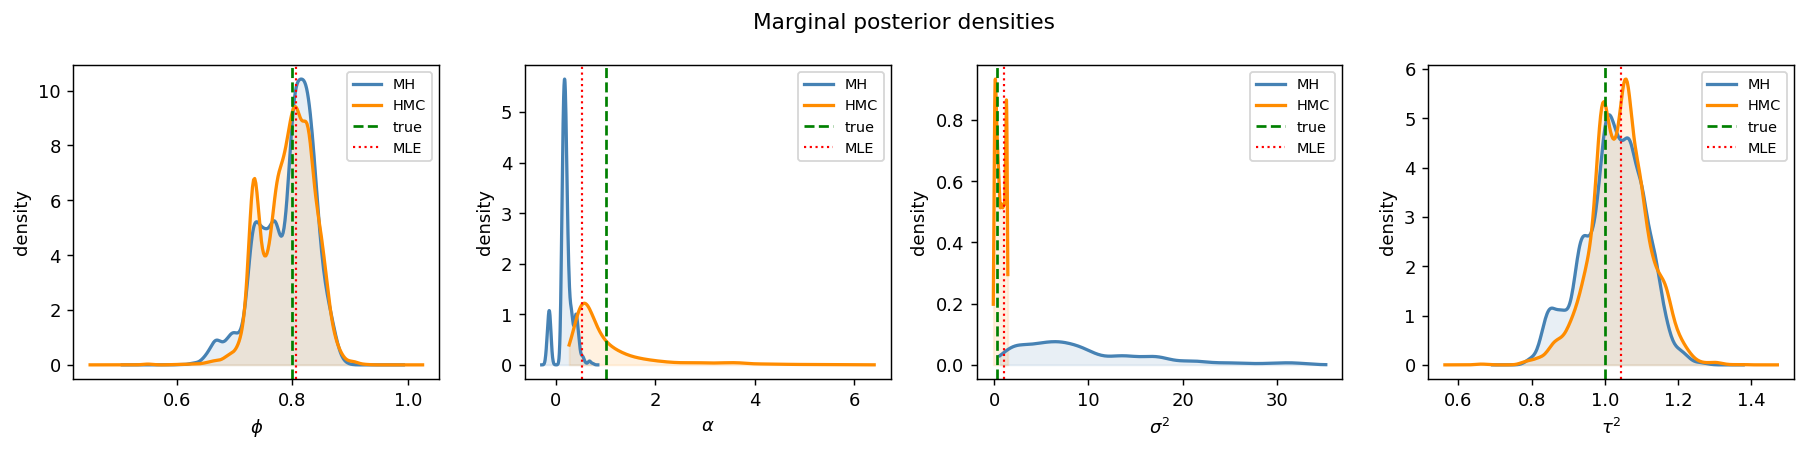

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Marginal posterior densities', fontsize=12)

for j, (ax, label, param) in enumerate(zip(axes, labels, PARAM_NAMES)):
    for samples, color, name in [
        (mh_con[:,  j], 'steelblue', 'MH'),
        (hmc_con[:, j], 'darkorange', 'HMC'),
    ]:
        kde  = gaussian_kde(samples, bw_method='scott')
        grid = np.linspace(samples.min() - 0.1, samples.max() + 0.1, 300)
        ax.plot(grid, kde(grid), color=color, lw=1.8, label=name)
        ax.fill_between(grid, kde(grid), alpha=0.12, color=color)

    ax.axvline(TRUE[param],  color='green', lw=1.5, ls='--', label='true')
    ax.axvline(mle_est[j],   color='red',   lw=1.2, ls=':',  label='MLE')
    ax.set_xlabel(label)
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 8. Log-likelihood trace

Shows how quickly each sampler reaches the high-likelihood region.  The
MLE log-likelihood is the theoretical upper bound for the sampled region.

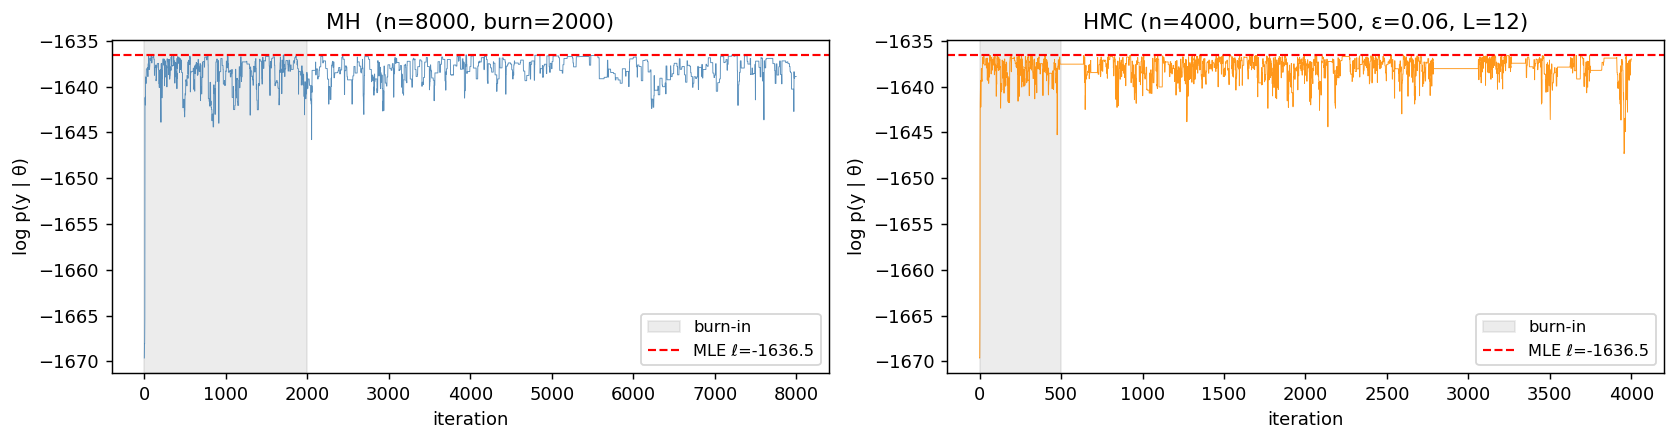

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

for ax, loglik, burn, color, title in [
    (axes[0], mh_loglik,  BURN,     'steelblue',  f'MH  (n={N_MH}, burn={BURN})'),
    (axes[1], hmc_loglik, BURN_HMC, 'darkorange',  f'HMC (n={N_HMC}, burn={BURN_HMC}, ε={STEP_SIZE}, L={N_LEAPFROG})'),
]:
    ax.plot(loglik, lw=0.5, color=color, alpha=0.9)
    ax.axvspan(0, burn, color='grey', alpha=0.15, label='burn-in')
    ax.axhline(mle_result.loglik, color='red', lw=1.2, ls='--', label=f'MLE ℓ={mle_result.loglik:.1f}')
    ax.set_title(title)
    ax.set_xlabel('iteration')
    ax.set_ylabel('log p(y | θ)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Autocorrelation and effective sample size

Lower autocorrelation → more independent samples per iteration → more
efficient posterior exploration.  HMC's gradient-guided proposals should
produce chains with significantly lower autocorrelation than random-walk MH.

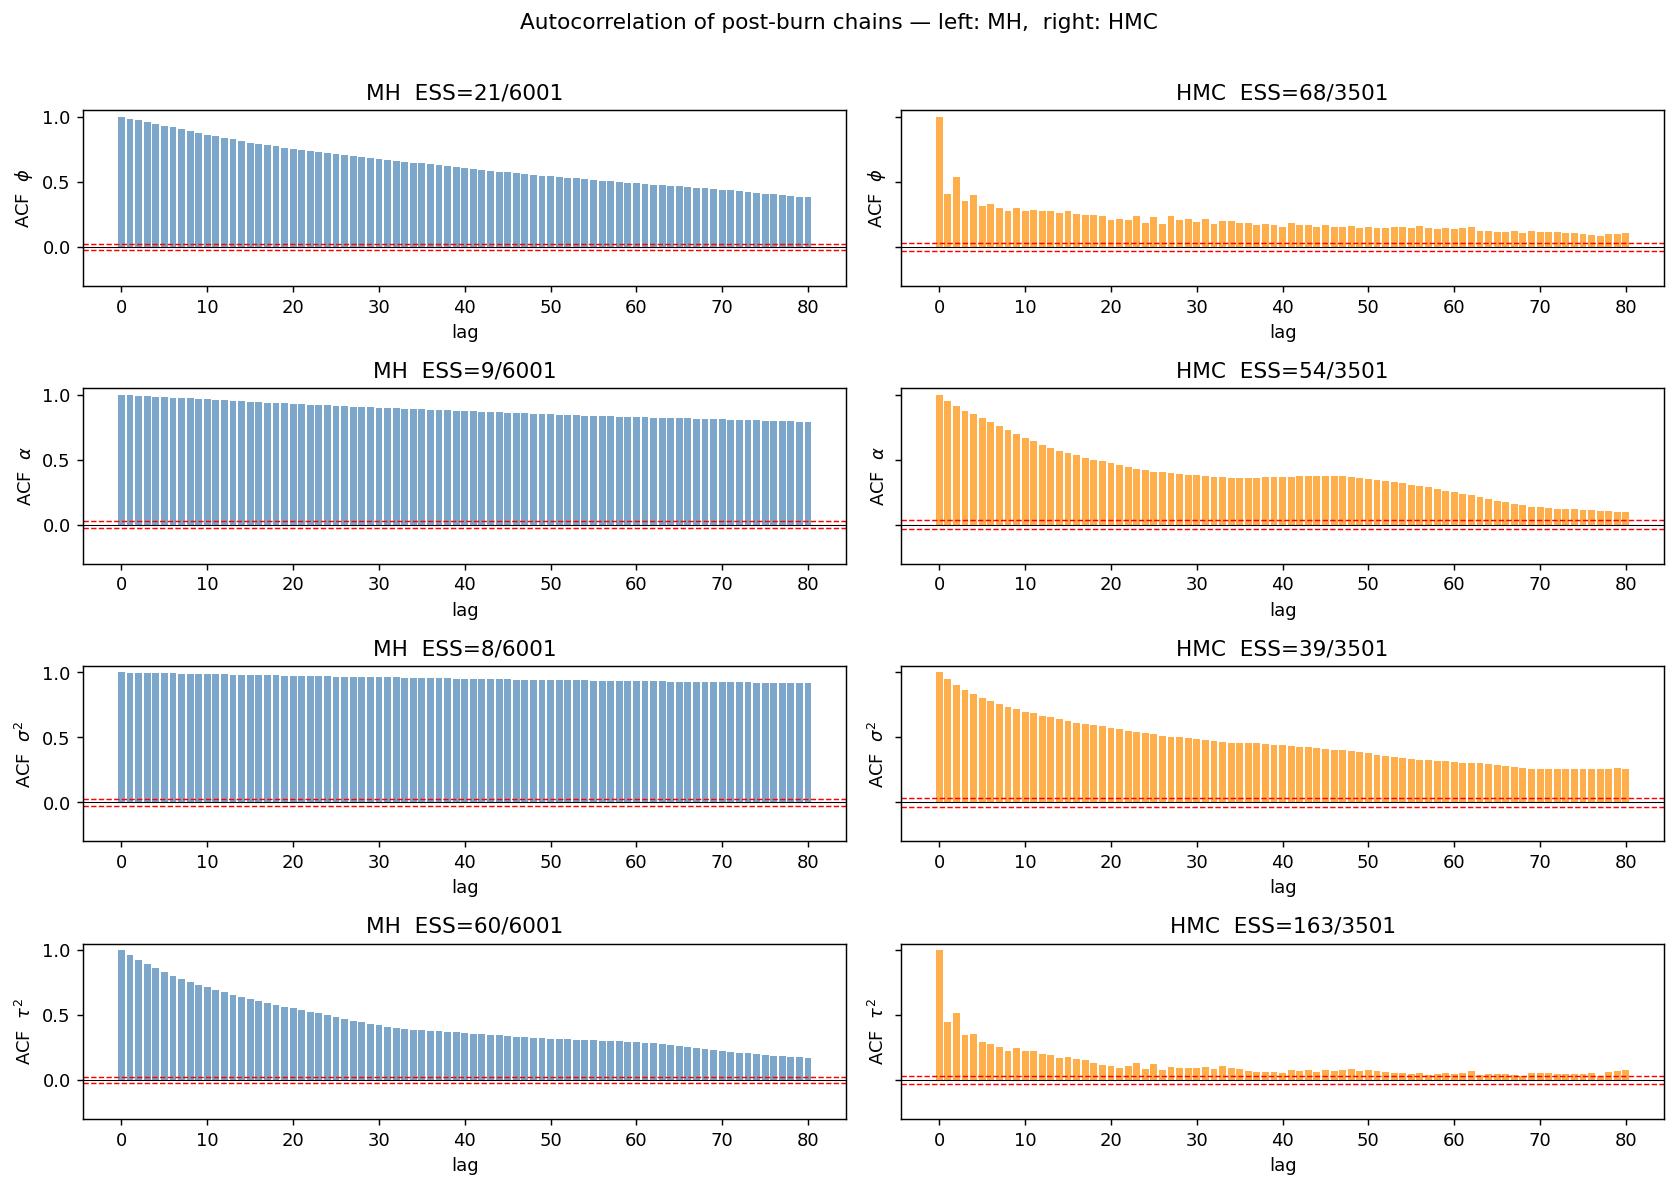


Param         MH ESS     HMC ESS   ESS ratio
--------------------------------------------
phi               21          68        3.30x
alpha              9          54        5.96x
sigma2             8          39        4.99x
tau2              60         163        2.71x


In [34]:
def autocorr(x, max_lag=100):
    x   = x - x.mean()
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag + 1)
    ac = np.array([np.mean(x[k:] * x[:len(x)-k]) for k in range(max_lag + 1)]) / var
    return ac

def ess(x):
    """Effective sample size via monotone sequence estimator."""
    n  = len(x)
    ac = autocorr(x, max_lag=min(n // 2, 500))
    # sum pairs until positive sum becomes negative
    rho_sum = 0.0
    for k in range(1, len(ac) - 1, 2):
        pair = ac[k] + ac[k + 1]
        if pair <= 0:
            break
        rho_sum += pair
    return n / (1 + 2 * rho_sum)

MAX_LAG = 80
fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharey='row')
fig.suptitle('Autocorrelation of post-burn chains — left: MH,  right: HMC', fontsize=12, y=1.01)

lags = np.arange(MAX_LAG + 1)
ess_table = []

for j, (label, param) in enumerate(zip(labels, PARAM_NAMES)):
    row = [param]
    for col, (samples, color, name) in enumerate([
        (mh_con[:,  j], 'steelblue',  'MH'),
        (hmc_con[:, j], 'darkorange', 'HMC'),
    ]):
        ax = axes[j, col]
        ac = autocorr(samples, max_lag=MAX_LAG)
        ax.bar(lags, ac, width=0.8, color=color, alpha=0.7)
        ax.axhline(0, color='black', lw=0.6)
        ax.axhline(1.96/np.sqrt(len(samples)), color='red', lw=0.8, ls='--')
        ax.axhline(-1.96/np.sqrt(len(samples)), color='red', lw=0.8, ls='--')
        ax.set_ylabel(f'ACF  {label}')
        ax.set_ylim(-0.3, 1.05)
        e = ess(samples)
        ax.set_title(f'{name}  ESS={e:.0f}/{len(samples)}')
        ax.set_xlabel('lag')
        row.append(e)
    ess_table.append(row)

plt.tight_layout()
plt.show()

print(f"\n{'Param':<8}  {'MH ESS':>10}  {'HMC ESS':>10}  {'ESS ratio':>10}")
print('-' * 44)
for param, mh_e, hmc_e in ess_table:
    print(f"{param:<8}  {mh_e:>10.0f}  {hmc_e:>10.0f}  {hmc_e/mh_e:>10.2f}x")

---
## 10. Joint posterior scatter plots

Most informative parameter pairs, overlaying MH (blue) and HMC (orange) samples.

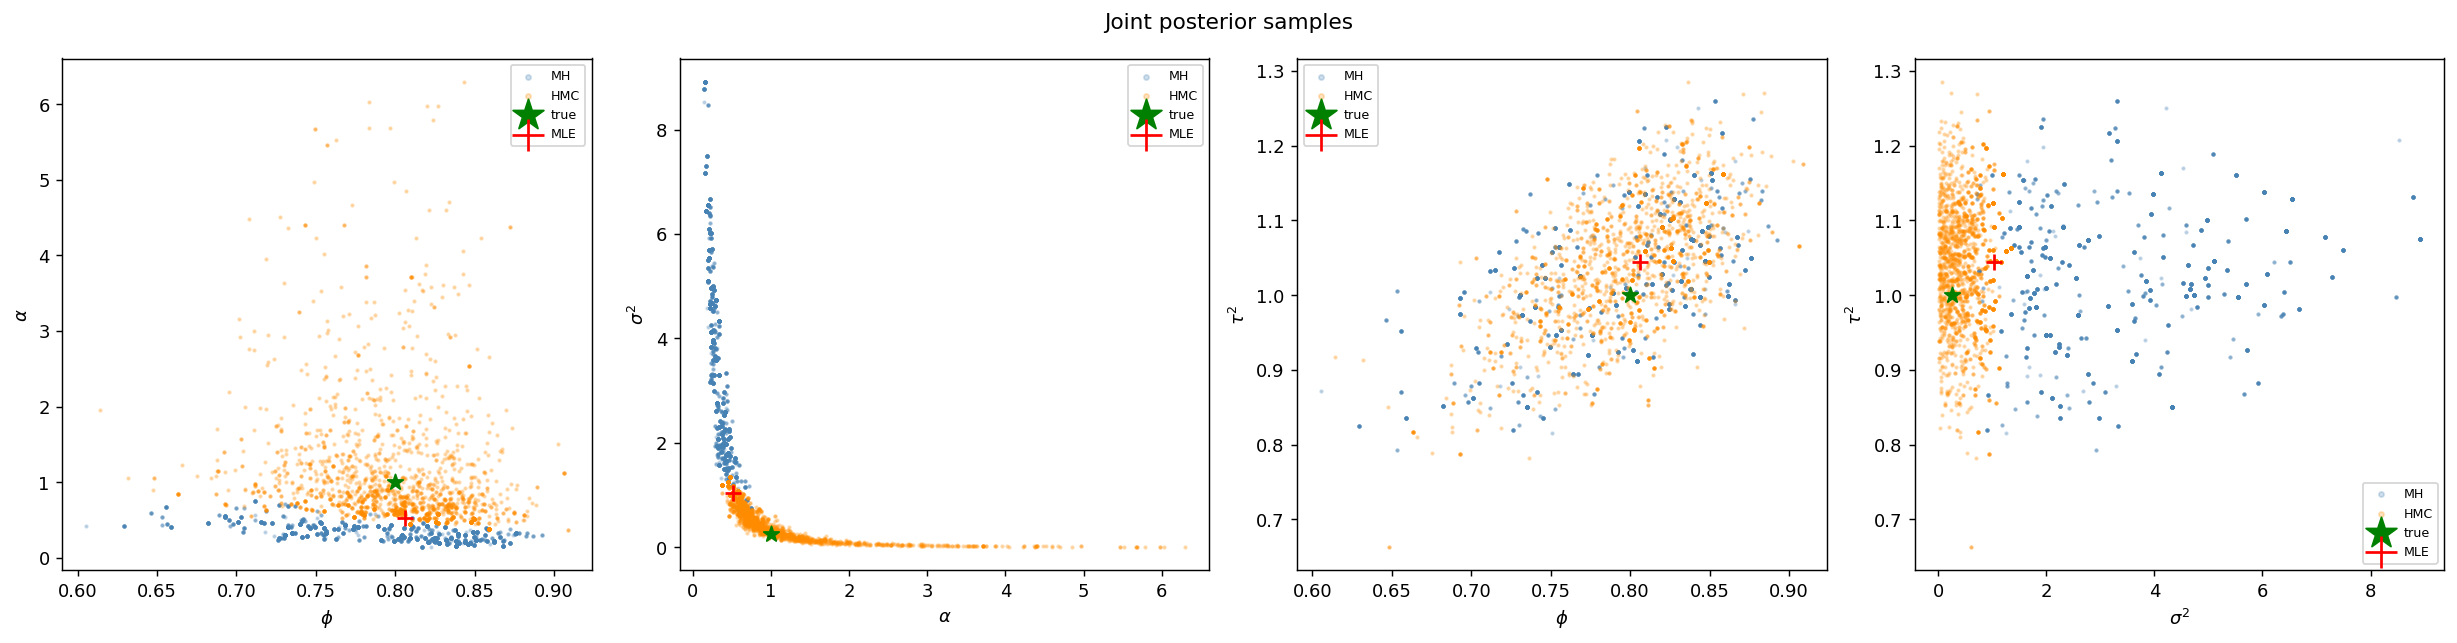

In [37]:
pairs  = [(0, 1), (1, 2), (0, 3), (2, 3)]  # (phi,alpha),(alpha,sigma2),(phi,tau2),(sigma2,tau2)
plabels = [r'$\phi$', r'$\alpha$', r'$\sigma^2$', r'$\tau^2$']

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
fig.suptitle('Joint posterior samples', fontsize=12)

n_plot = min(2000, len(mh_con), len(hmc_con))

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(mh_con[:n_plot,  i], mh_con[:n_plot,  j],
               s=2, alpha=0.25, color='steelblue',  label='MH')
    ax.scatter(hmc_con[:n_plot, i], hmc_con[:n_plot, j],
               s=2, alpha=0.25, color='darkorange', label='HMC')
    ax.scatter([TRUE[PARAM_NAMES[i]]], [TRUE[PARAM_NAMES[j]]],
               s=80, color='green', zorder=5, marker='*', label='true')
    ax.scatter([mle_est[i]], [mle_est[j]],
               s=80, color='red', zorder=5, marker='+', linewidths=1.5, label='MLE')
    ax.set_xlabel(plabels[i]); ax.set_ylabel(plabels[j])
    ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

We can see quite clearly the weak identifiability issue of $\alpha$ and $\sigma^2$ in the second graph, where $\alpha^2 \cdot \sigma^2$ is well estimated but the individual parameters show an inverse relationship. The MH chain covered very small $\alpha$ and large $\sigma^2$ values, while the HMC chain covered large $\alpha$ and small $\sigma^2$.

---
## 11. Summary

Key takeaways from the three methods on this model:

In [36]:
print('=' * 62)
print(f'  T = {T} observations')
print('=' * 62)
print()
print('MLE')
print(f'  log-likelihood : {mle_result.loglik:.2f}')
print(f'  converged      : {mle_result.success}')
print()
print('Metropolis-Hastings')
print(f'  iterations     : {N_MH}  (burn {BURN})')
print(f'  accept rate    : {mh.accept_rate:.3f}')
total_mh_ess = sum(r[1] for r in ess_table)
print(f'  total ESS      : {total_mh_ess:.0f}  (all params)')
print()
print('Hamiltonian MC')
print(f'  iterations     : {N_HMC}  (burn {BURN_HMC})')
print(f'  step_size      : {STEP_SIZE},  L={N_LEAPFROG}')
print(f'  accept rate    : {hmc.accept_rate:.3f}')
total_hmc_ess = sum(r[2] for r in ess_table)
print(f'  total ESS      : {total_hmc_ess:.0f}  (all params)')
print(f'  ESS / Kalman pass : {total_hmc_ess / (N_HMC * (N_LEAPFROG + 2)):.3f}')
print()
print('─' * 62)
print(f"{'':28} {'MH':>10}  {'HMC':>10}")
print(f"{'ESS per iteration':<28} {total_mh_ess/N_MH:>10.3f}  {total_hmc_ess/N_HMC:>10.3f}")
print(f"{'ESS per Kalman pass':<28} {total_mh_ess/N_MH:>10.3f}  {total_hmc_ess/(N_HMC*(N_LEAPFROG+2)):>10.3f}")

  T = 1000 observations

MLE
  log-likelihood : -1636.52
  converged      : True

Metropolis-Hastings
  iterations     : 8000  (burn 2000)
  accept rate    : 0.111
  total ESS      : 98  (all params)

Hamiltonian MC
  iterations     : 4000  (burn 500)
  step_size      : 0.06,  L=12
  accept rate    : 0.482
  total ESS      : 325  (all params)
  ESS / Kalman pass : 0.006

──────────────────────────────────────────────────────────────
                                     MH         HMC
ESS per iteration                 0.012       0.081
ESS per Kalman pass               0.012       0.006
